<a href="https://colab.research.google.com/github/DataAnalytics808/DASC-522-demo-repository/blob/main/demos/Week_07_1_Regression_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Regression Tensorflow Example

### Basic regression: Predict fuel efficiency

In a *regression* problem, we aim to predict the output of a continuous value, like a price or a probability. Contrast this with a *classification* problem, where we aim to select a class from a list of classes (for example, where a picture contains an apple or an orange, recognizing which fruit is in the picture).

This notebook uses the classic [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) Dataset and builds a model to predict the fuel efficiency of late-1970s and early 1980s automobiles. To do this, we'll provide the model with a description of many automobiles from that time period. This description includes attributes like: cylinders, displacement, horsepower, and weight.

This example uses the `tf.keras` API, see [this guide](https://www.tensorflow.org/guide/keras) for details.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# if not using colab may need to install seaborn with # !pip install -q seaborn

# Make numpy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

# set demo mode
use_normalization = 0

In [ ]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import preprocessing # updated

print(tf.__version__)

2.19.0


### The Auto MPG dataset

The dataset is available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).


### Get the data
First download and import the dataset using pandas:

In [ ]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [ ]:
dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


### Clean the data

The dataset contains a few unknown values.

In [ ]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

Drop those rows to keep this initial tutorial simple.

In [ ]:
dataset = dataset.dropna()

Make sure that worked

In [ ]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

The `"Origin"` column is really categorical, not numeric. So convert that to a one-hot:

Note: You can set up the `keras.Model` to do this kind of transformation for you. That's beyond the scope of this tutorial. See the [preprocessing layers](../structured_data/preprocessing_layers.ipynb) or [Loading CSV data](../load_data/csv.ipynb) tutorials for examples.

In [ ]:
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

In [ ]:
dataset = pd.get_dummies(dataset, dtype='int',prefix='', prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0,0,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,1,0,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0,0,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,0,0,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,0,0,1


### Split the data into train and test

Now split the dataset into a training set and a test set.

We will use the test set in the final evaluation of our models.

In [ ]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
# train_dataset = dataset.sample(frac=0.8)

test_dataset = dataset.drop(train_dataset.index)  # <-- elegant!

print(train_dataset.shape)
print(test_dataset.shape)
print(" ")

print(train_dataset.tail())

(314, 10)
(78, 10)
 
      MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  Model Year  Europe  Japan  USA
281  19.8          6         200.0        85.0  2990.0          18.2          79       0      0    1
229  16.0          8         400.0       180.0  4220.0          11.1          77       0      0    1
150  26.0          4         108.0        93.0  2391.0          15.5          74       0      1    0
145  32.0          4          83.0        61.0  2003.0          19.0          74       0      1    0
182  28.0          4         107.0        86.0  2464.0          15.5          76       1      0    0


### Data understanding

Have a quick look at the joint distribution of a few pairs of columns from the training set.

Looking at the top row it should be clear that the fuel efficiency (MPG) is a function of all the other parameters. Looking at the other rows it should be clear that they are each functions of eachother.

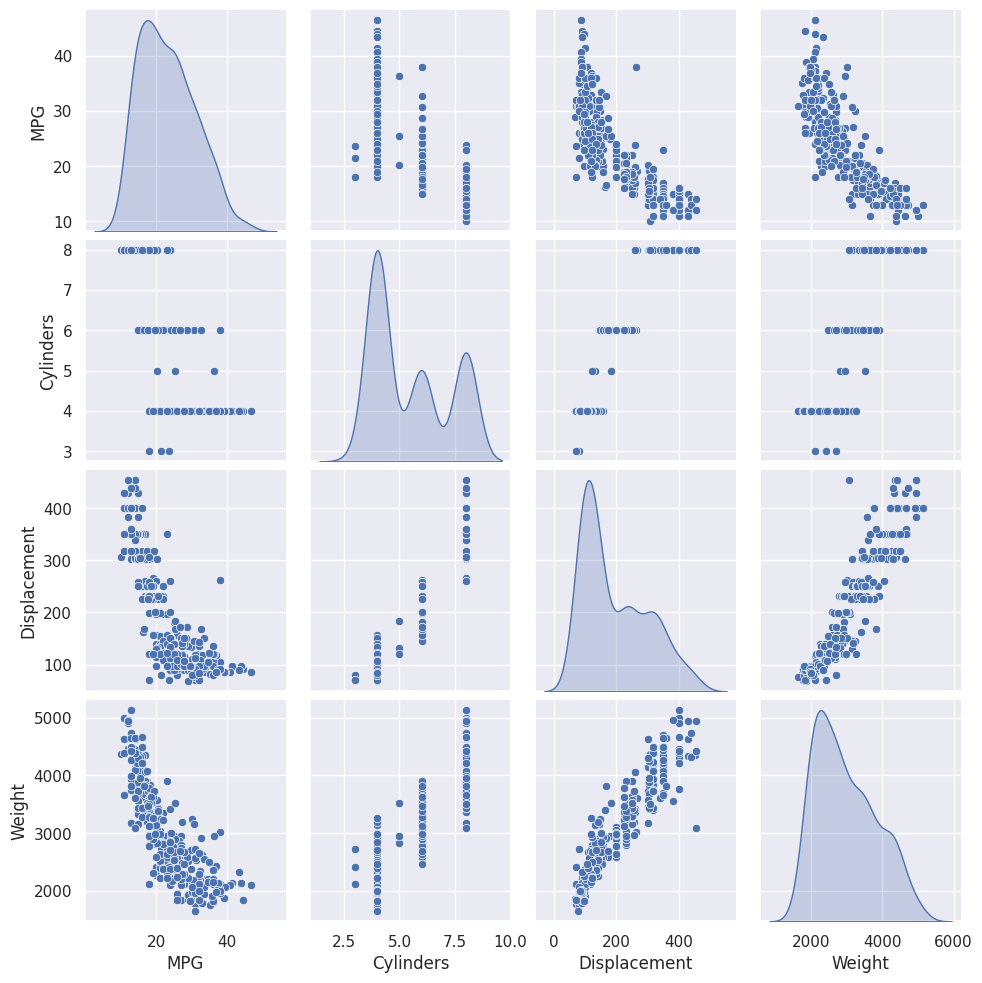

In [ ]:
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')



Also look at the overall statistics, note how each feature covers a very different range:

In [ ]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0


### Split features from labels

Separate the target value, the "label", from the features. This label is the value that you will train the model to predict.

In [ ]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

print(train_features.shape)

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

LR_train_features = train_features['Horsepower']  # save this for LR later on

print(train_features.shape)


(314, 10)
(314, 9)


## Normalization

In the table of statistics it's easy to see how different the ranges of each feature are.

In [ ]:
train_dataset.describe().transpose()[['mean', 'std']]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642
Europe,0.178344,0.383413
Japan,0.197452,0.398712
USA,0.624204,0.485101


It is good practice to normalize features that use different scales and ranges.

One reason this is important is because the features are multiplied by the model weights. So the scale of the outputs and the scale of the gradients are affected by the scale of the inputs.

Although a model *might* converge without feature normalization, normalization makes training much more stable.

### The Normalization layer
The `Normalization` layer is a clean and simple way to build that preprocessing into your model.

The first step is to create the layer:

In [ ]:
normalizer = layers.Normalization()

Then `.adapt()` it to the data:

In [ ]:
normalizer.adapt(np.array(train_features))

This calculates the mean and variance, and stores them in the layer.

In [ ]:
import numpy

print(normalizer.mean.numpy())
print(" ")


print(numpy.sqrt( normalizer.variance.numpy() ))

[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]
 
[[  1.697 104.165  38.036 842.554   2.785   3.67    0.383   0.398   0.484]]


When the layer is called it returns the input data, with each feature independently normalized:

In [ ]:
first = np.array(train_features[:1], dtype=np.float32)  # Change the data type to float32

with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normalizer(tf.convert_to_tensor(first)).numpy())  # Convert to Tensor before passing to normalizer

First example: [[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]

Normalized: [[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


## Linear regression with NN

Before building a DNN model, start with a linear regression.

### One Variable

Start with a single-variable linear regression, to predict `MPG` from `Horsepower`.

Training a model with `tf.keras` typically starts by defining the model architecture.

In this case use a `keras.Sequential` model. This model represents a sequence of steps. In this case there are two steps:

* Normalize the input `horsepower`.
* Apply a linear transformation ($y = mx+b$) to produce 1 output using `layers.Dense`.

The number of _inputs_ can either be set by the `input_shape` argument, or automatically when the model is run for the first time.

First create the horsepower `Normalization` layer:

In [ ]:
# using tensorflow 2.17.0
horsepower = train_features[['Horsepower']]   #  <---- new
horsepower_values = horsepower.values

horsepower_normalizer = layers.Normalization(axis=-1)
horsepower_normalizer.adapt(horsepower_values)


Build the sequential model:

In [ ]:
if(use_normalization):
  horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
  ])

  # Insight into the weights
  first_layer_weights = horsepower_model.layers[1].get_weights()[0]
  first_layer_biases  = horsepower_model.layers[1].get_weights()[1]

  print(f"1st layer weight is {first_layer_weights} and bias is {first_layer_biases}")

  horsepower_model.summary()

else:  # this is a demo so we can see the weights
  horsepower_model = tf.keras.Sequential([
    layers.Dense(units=1)
  ])








This model will predict `MPG` from `Horsepower`.

Run the untrained model on the first 10 horse-power values. The output won't be good, but you'll see that it has the expected shape, `(10,1)`:

In [ ]:
horsepower_model.predict(horsepower[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


array([[-3.803],
       [-4.462],
       [-8.113],
       [-3.195],
       [-3.397],
       [-4.564],
       [-3.043],
       [-3.397],
       [-4.817],
       [-4.462]], dtype=float32)

Check the output

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


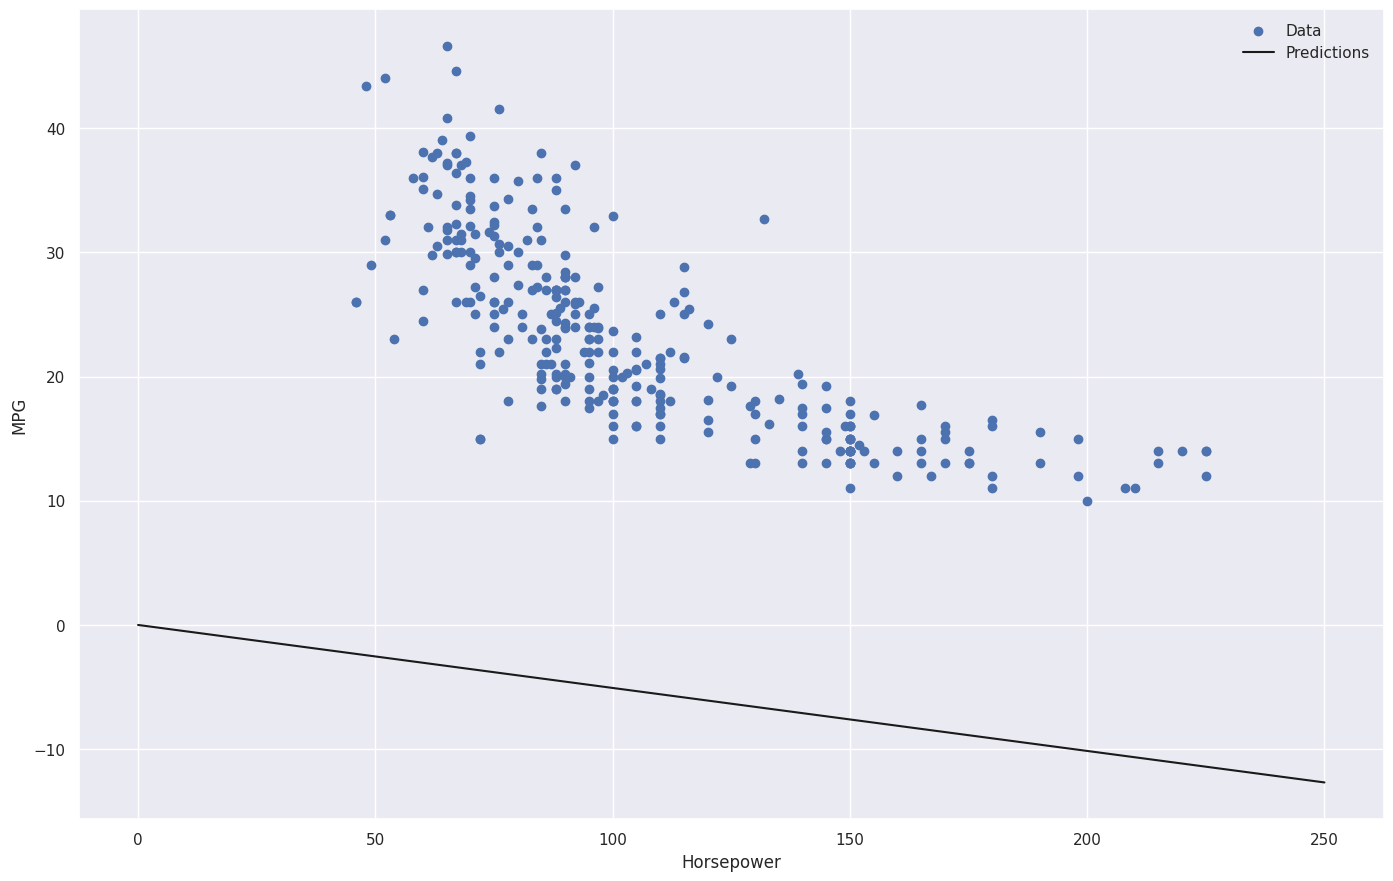

In [ ]:
def plot_horsepower(x, y):
  plt.scatter(train_features['Horsepower'], train_labels, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('Horsepower')
  plt.ylabel('MPG')
  plt.legend()

x = np.linspace(0.0, 250, 251)  #
x_tensor = tf.constant(x, shape=(251, 1))  # Convert NumPy array to TensorFlow tensor with a defined shape

y = horsepower_model.predict(x_tensor)

plot_horsepower(x,y)

In [ ]:
x

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

Once the model is built, configure the training procedure using the `Model.compile()` method. The most important arguments to compile are the `loss` and the `optimizer` since these define what will be optimized (`mean_absolute_error`) and how (using the `optimizers.Adam`).

In [ ]:
horsepower_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

# could use mean_squared_error

Once the training is configured, use `Model.fit()` to execute the training:

In [ ]:
%%time
history = horsepower_model.fit(
    train_features['Horsepower'], train_labels,
    epochs=100,
    # suppress logging if 0
    verbose=1,
    # Calculate validation results on 20% of the training data
    validation_split = 0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 16.7958 - val_loss: 14.7863
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12.6153 - val_loss: 14.9391
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12.4155 - val_loss: 12.9795
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.5902 - val_loss: 12.7769
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 11.6205 - val_loss: 12.2072
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.2389 - val_loss: 11.9768
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.2113 - val_loss: 11.9283
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.2342 - val_loss: 12.2440
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.0974 - val_loss: 11.5221
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.7195 - val_loss: 11.3984
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.6102 - val_loss: 11.5248
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step -

Visualize the model's training progress using the stats stored in the `history` object.

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,val_loss,epoch
95,4.276089,4.318014,95
96,4.008158,4.391267,96
97,4.139122,4.398489,97
98,4.895525,4.506683,98
99,4.402096,4.073043,99


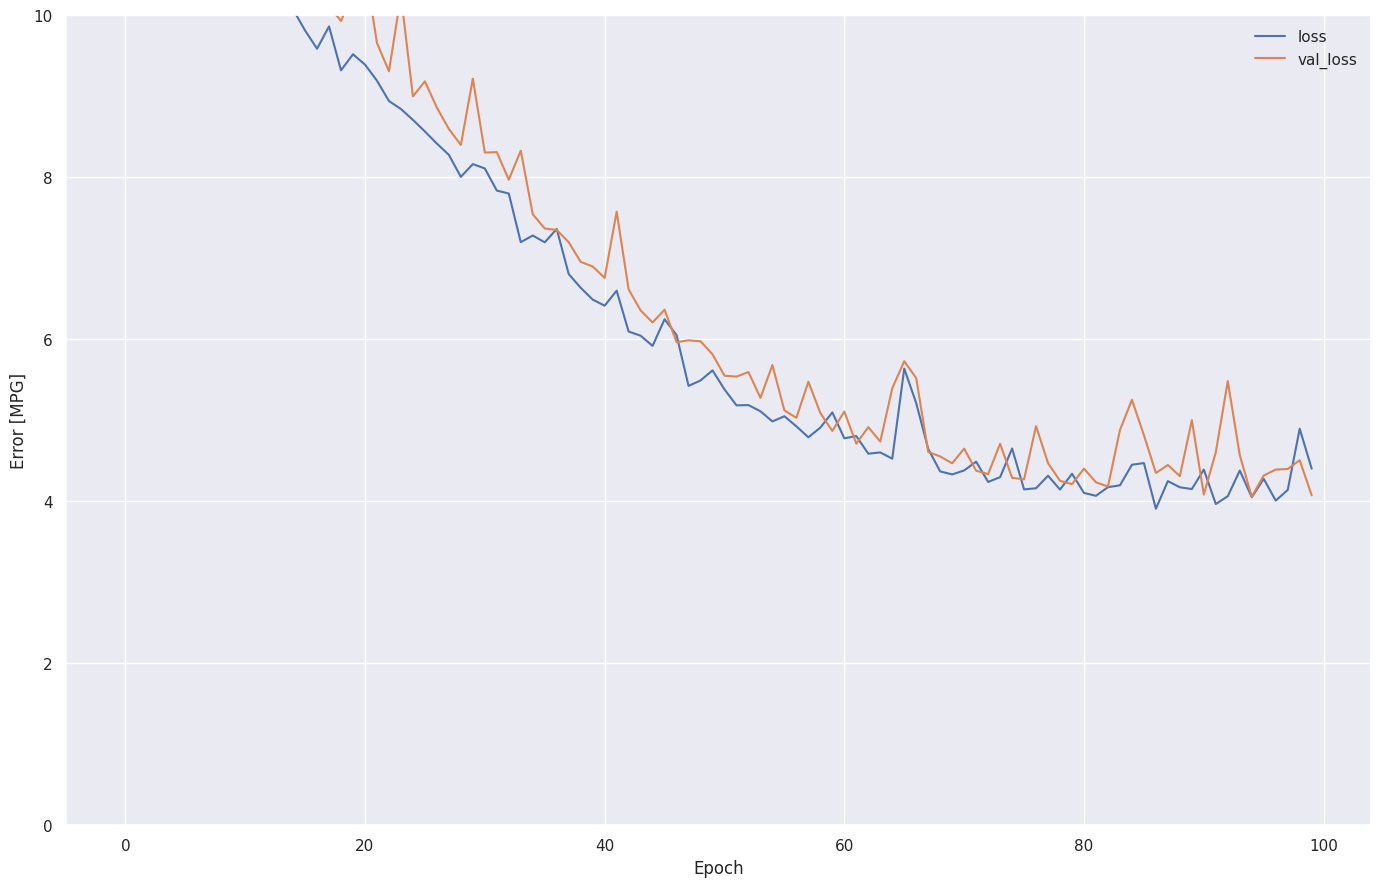

In [ ]:
def plot_loss(history,y_lim=10):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, y_lim])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)


plot_loss(history)

# another way to plot training history from 6A
# pyplot.plot(history.history['loss'], label='train')
# pyplot.plot(history.history['val_loss'], label='test')
# pyplot.legend()
# pyplot.show()

Collect the results on the test set, for later:

In [ ]:
test_results = {}

test_results['horsepower_model'] = horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels, verbose=0)

SInce this is a single variable regression it's easy to look at the model's predictions as a function of the input:

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


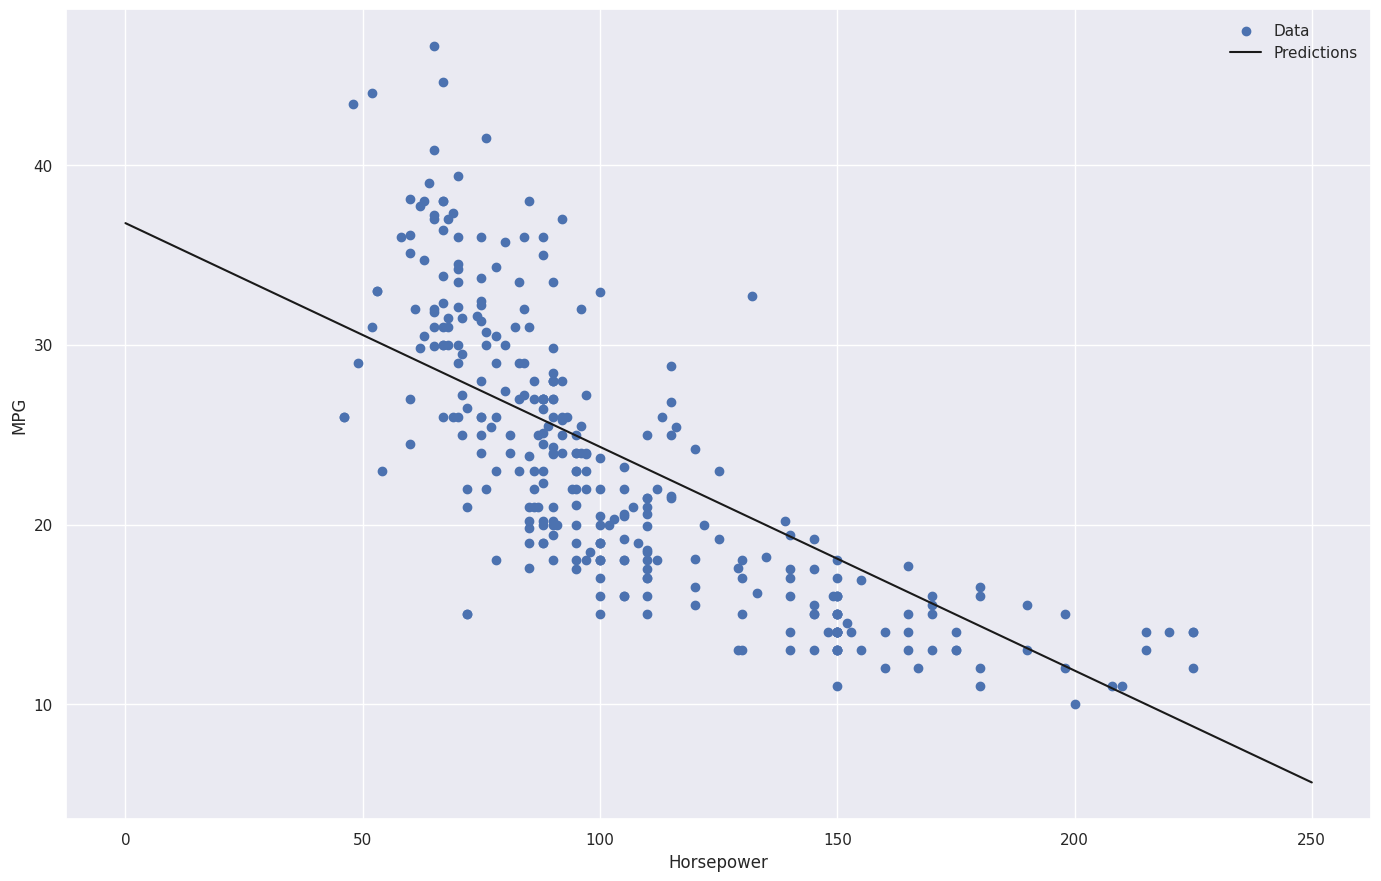

In [ ]:
x = np.linspace(0.0, 250, 251)  #
x_tensor = tf.constant(x, shape=(251, 1))  # Convert NumPy array to TensorFlow tensor with a defined shape

y = horsepower_model.predict(x_tensor)

plot_horsepower(x,y)

In [ ]:
horsepower[:10]

,Horsepower
146,75.0
282,88.0
69,160.0
378,63.0
331,67.0
257,90.0
310,60.0
328,67.0
125,95.0
108,88.0


In [ ]:
horsepower_model.predict([horsepower[:10]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_196
Received: inputs=('Tensor(shape=(10, 1))',)
  warnings.warn(msg)


array([[27.428],
       [25.811],
       [16.856],
       [28.92 ],
       [28.423],
       [25.562],
       [29.294],
       [28.423],
       [24.94 ],
       [25.811]], dtype=float32)

Pull out weights

In [ ]:
# first_layer_weights = horsepower_model.layers[1].get_weights()[0]
# first_layer_biases  = horsepower_model.layers[1].get_weights()[1]

# print(f"1st layer weight is {first_layer_weights} and bias is {first_layer_biases}")

for layer in horsepower_model.layers: print(layer.get_config(), layer.get_weights(), "\n")

{'name': 'dense_83', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None, 'quantization_config': None} [array([[-0.124]], dtype=float32), array([36.757], dtype=float32)] 



Check with Classical Linear Regression

In [ ]:
# import statsmodels.formula.api as smf
import statsmodels.api as sm

X_labels = sm.add_constant(LR_train_features)

model_LRcheck = sm.OLS(train_labels, X_labels)

# LR_predictions = model_LRcheck.predict(X_labels)
results = model_LRcheck.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     439.0
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.83e-61
Time:                        00:21:03   Log-Likelihood:                -949.26
No. Observations:                 314   AIC:                             1903.
Df Residuals:                     312   BIC:                             1910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.5763      0.826     47.922      0.0

### Multiple inputs

You can use an almost identical setup to make predictions based on multiple inputs. This model still does the same $y = mx+b$ except that $m$ is a matrix and $b$ is a vector.

This time use the `Normalization` layer that was adapted to the whole dataset.

Data refresh

In [ ]:
train_features.tail()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
281,6,200.0,85.0,2990.0,18.2,79,0,0,1
229,8,400.0,180.0,4220.0,11.1,77,0,0,1
150,4,108.0,93.0,2391.0,15.5,74,0,1,0
145,4,83.0,61.0,2003.0,19.0,74,0,1,0
182,4,107.0,86.0,2464.0,15.5,76,1,0,0


In [ ]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])


When you call this model on a batch of inputs, it produces `units=1` outputs for each example.

In [ ]:
linear_model.predict(train_features[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


array([[ 0.66 ],
       [ 1.341],
       [ 0.852],
       [ 1.322],
       [-1.201],
       [ 0.972],
       [-1.248],
       [-2.233],
       [ 0.495],
       [-1.544]], dtype=float32)

When you call the model it's weight matrices will be built. Now you can see that the `kernel` (the $m$ in $y=mx+b$) has a shape of `(9,1)`.

In [ ]:
linear_model.layers[1].kernel

<Variable path=sequential_32/dense_84/kernel, shape=(9, 1), dtype=float32, value=[[-0.606]
 [ 0.681]
 [ 0.693]
 [-0.506]
 [ 0.092]
 [ 0.356]
 [-0.735]
 [-0.44 ]
 [ 0.649]]>

Use the same `compile` and `fit` calls as for the single input `horsepower` model:

In [ ]:
linear_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [ ]:
%%time
history = linear_model.fit(
    train_features, train_labels,
    epochs=100,
    # suppress logging
    verbose=0,
    # Calculate validation results on 20% of the training data
    validation_split = 0.2)

CPU times: user 9.4 s, sys: 2.16 s, total: 11.6 s
Wall time: 12.2 s


Using all the inputs achieves a much lower training and validation error than the `horsepower` model:

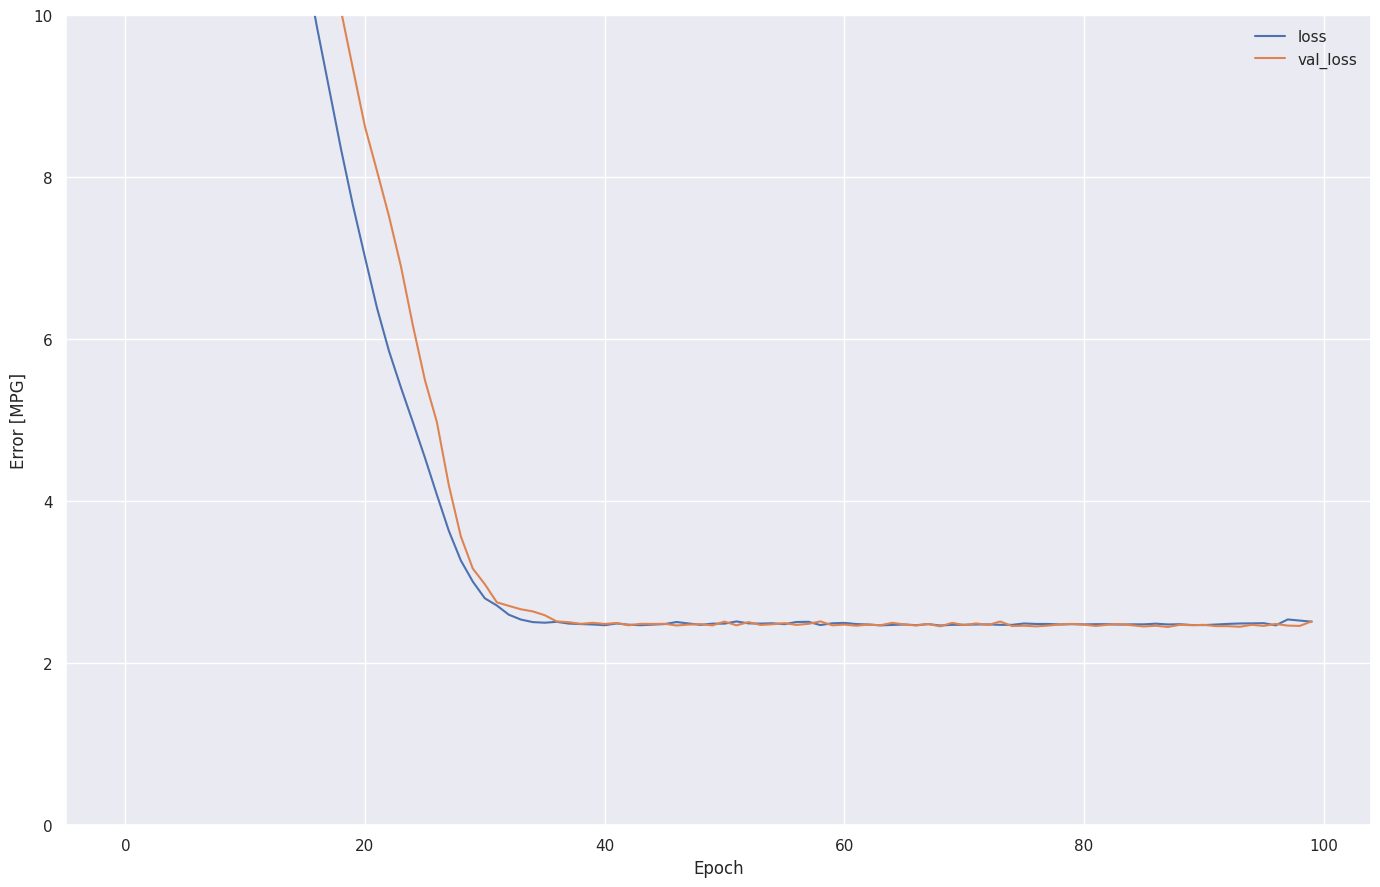

In [ ]:
plot_loss(history)

Collect the results on the test set, for later:

In [ ]:
test_results['linear_model'] = linear_model.evaluate(
    test_features, test_labels, verbose=0)

Remove normalization for comparison

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 508.9010 - val_loss: 281.2745
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 163.9710 - val_loss: 42.5847
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 92.4278 - val_loss: 124.0958
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 62.6800 - val_loss: 61.5272
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 50.0308 - val_loss: 72.8766
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 38.9997 - val_loss: 23.8023
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.4287 - val_loss: 14.1126
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.6698 - val_loss: 44.7143
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 53.5418 - val_loss: 97.2193
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52.0253 - val_loss: 40.3729
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.9125 - val_loss: 11.6719
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/st

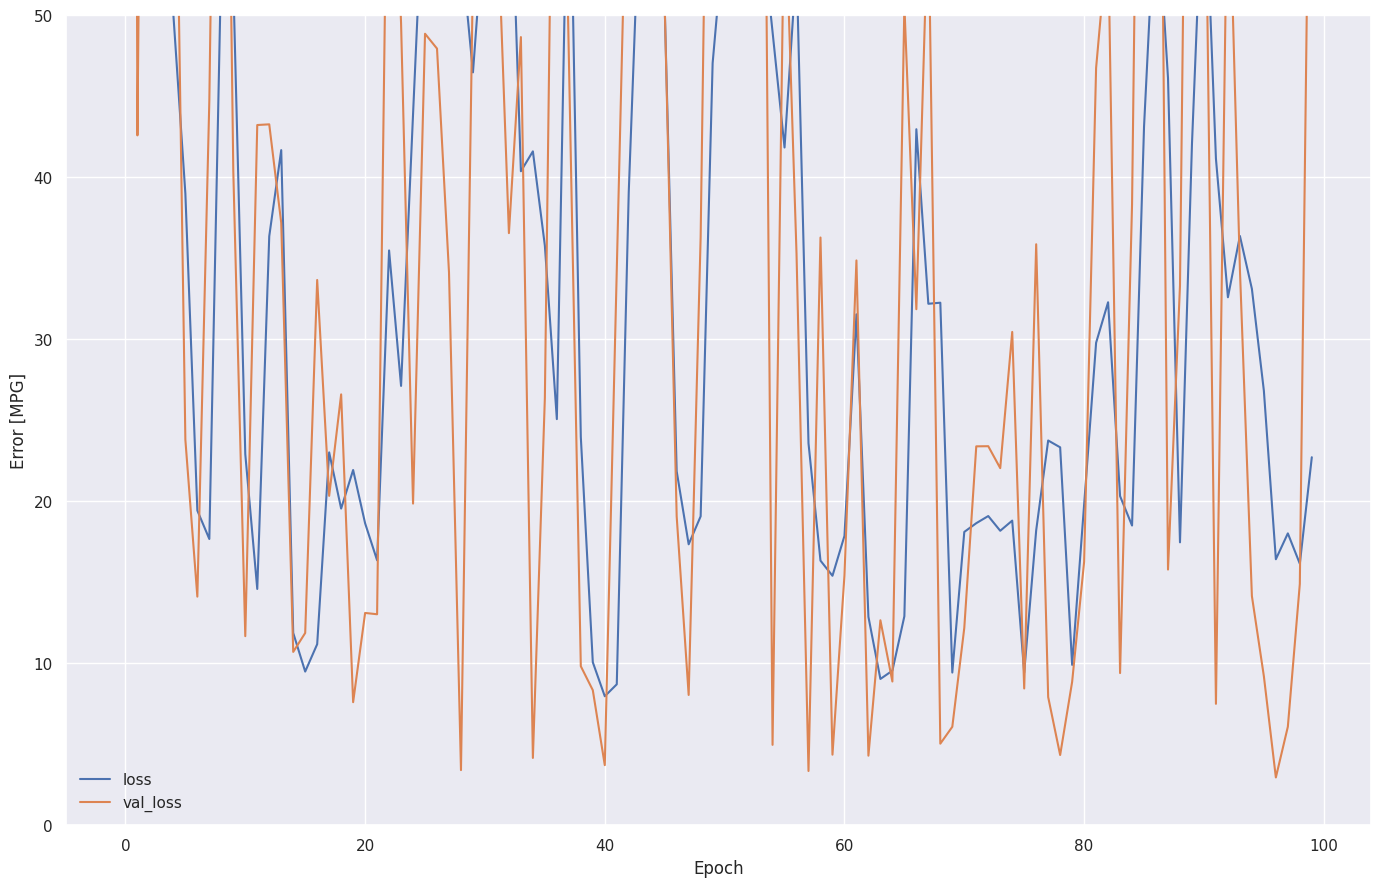

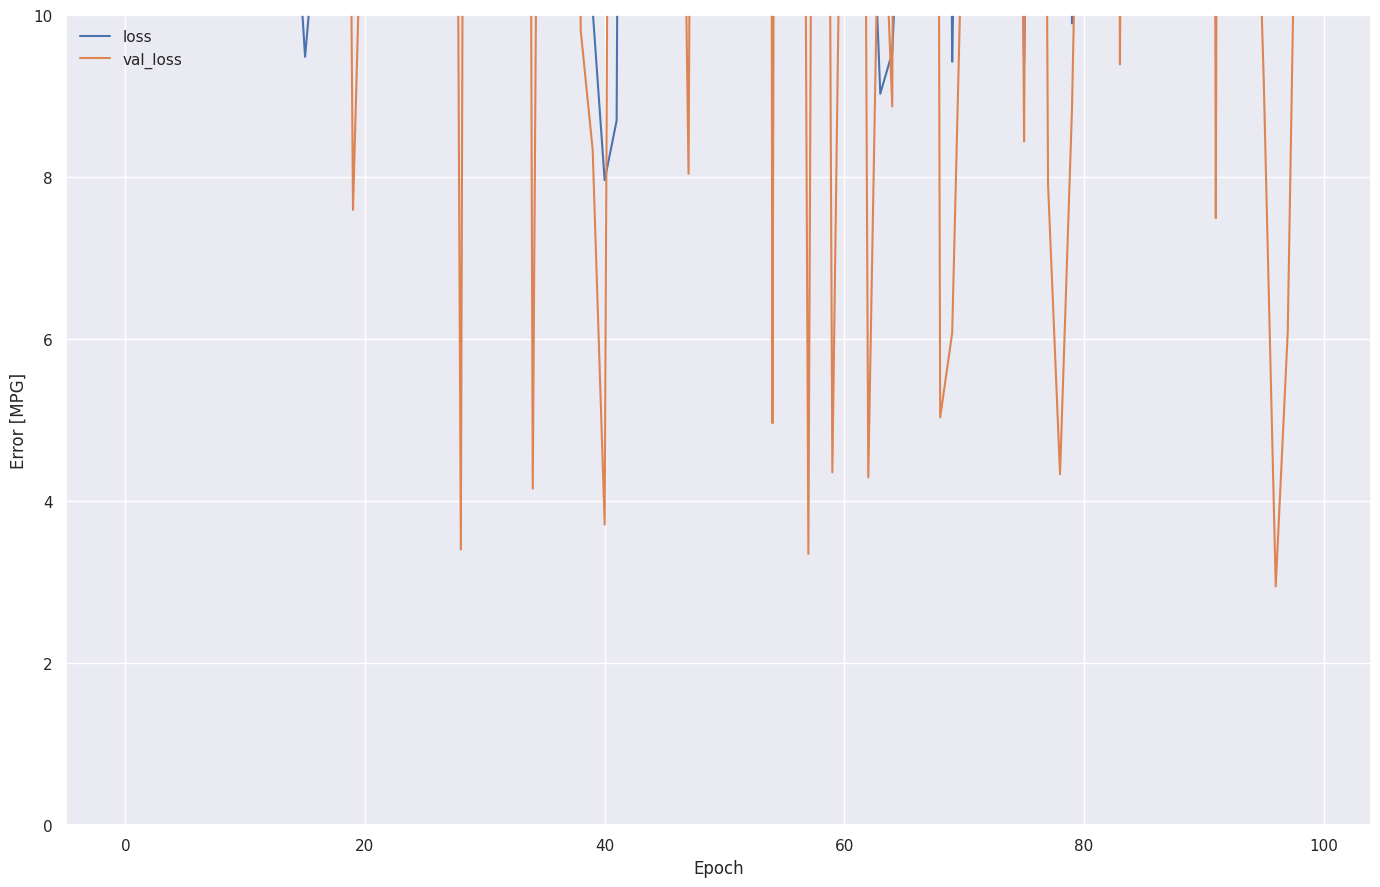

In [ ]:

linear_model_noNorm = tf.keras.Sequential([
    layers.Dense(units=1)
])

linear_model_noNorm.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

history = linear_model_noNorm.fit(
    train_features, train_labels,
    epochs=100,
    # suppress logging
    verbose=1,
    # Calculate validation results on 20% of the training data
    validation_split = 0.2)

plt.figure(0)
plot_loss(history, 50)
plt.figure(1)
plot_loss(history, 10)

Check with Classical Linear Regression

In [ ]:
# import statsmodels.formula.api as smf
import statsmodels.api as sm

X_labels_9var = sm.add_constant(train_features)

model_LRcheck = sm.OLS(train_labels, X_labels_9var)

# LR_predictions = model_LRcheck.predict(X_labels)
results = model_LRcheck.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     169.4
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          2.07e-107
Time:                        00:21:30   Log-Likelihood:                -821.16
No. Observations:                 314   AIC:                             1660.
Df Residuals:                     305   BIC:                             1694.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -11.1477      3.985     -2.797   

In [ ]:
for layer in linear_model_noNorm.layers: print(layer.get_config(), layer.get_weights(), "\n")

{'name': 'dense_85', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None, 'quantization_config': None} [array([[-0.439],
       [ 0.061],
       [ 0.039],
       [ 0.013],
       [ 0.687],
       [ 0.475],
       [ 0.076],
       [ 2.036],
       [-0.101]], dtype=float32), array([0.372], dtype=float32)] 



In [ ]:
linear_model_noNorm.layers[0].kernel




<Variable path=sequential_33/dense_85/kernel, shape=(9, 1), dtype=float32, value=[[-0.439]
 [ 0.061]
 [ 0.039]
 [ 0.013]
 [ 0.687]
 [ 0.475]
 [ 0.076]
 [ 2.036]
 [-0.101]]>

## A DNN regression

The previous section implemented linear models for single and multiple inputs.

This section implements single-input and multiple-input DNN models. The code is basically the same except the model is expanded to include some "hidden"  non-linear layers. The name "hidden" here just means not directly connected to the inputs or outputs.

These models will contain a few more layers than the linear model:

* The normalization layer.
* Two hidden, nonlinear, `Dense` layers using the `relu` nonlinearity.
* A linear single-output layer.

Both will use the same training procedure so the `compile` method is included in the `build_and_compile_model` function below.

In [ ]:
def build_and_compile_model(norm):
  model = keras.Sequential([
      norm,
      layers.Dense(64, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

### One variable

Start with a DNN model for a single input: "Horsepower"

In [ ]:
dnn_horsepower_model = build_and_compile_model(horsepower_normalizer)

This model has quite a few more trainable parameters than the linear models.

In [ ]:
dnn_horsepower_model.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (314, 1)               │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

Train the model:

In [ ]:
# %%time
history = dnn_horsepower_model.fit(
     train_features[['Horsepower']],
     train_labels,
     epochs = 100,
     validation_split=0.2,
     verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - loss: 23.0885 - val_loss: 23.4617
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.8519 - val_loss: 23.2223
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.6175 - val_loss: 22.9426
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.3174 - val_loss: 22.5763
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.9209 - val_loss: 22.0873
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.3969 - val_loss: 21.4475
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.7160 - val_loss: 20.6235
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.8393 - val_loss: 19.5779
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 18.7226 - val_loss: 18.2670
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17.3595 - val_loss: 16.7492
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 15.8323 - val_loss: 15.0608
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 

In [ ]:
print(horsepower.shape)

(314, 1)


In [ ]:
horsepower_column = train_features[['Horsepower']]  # Replace 'Horsepower' with the actual column name if different
print(horsepower_column.shape)

(314, 1)


This model does slightly better than the linear-horsepower model.

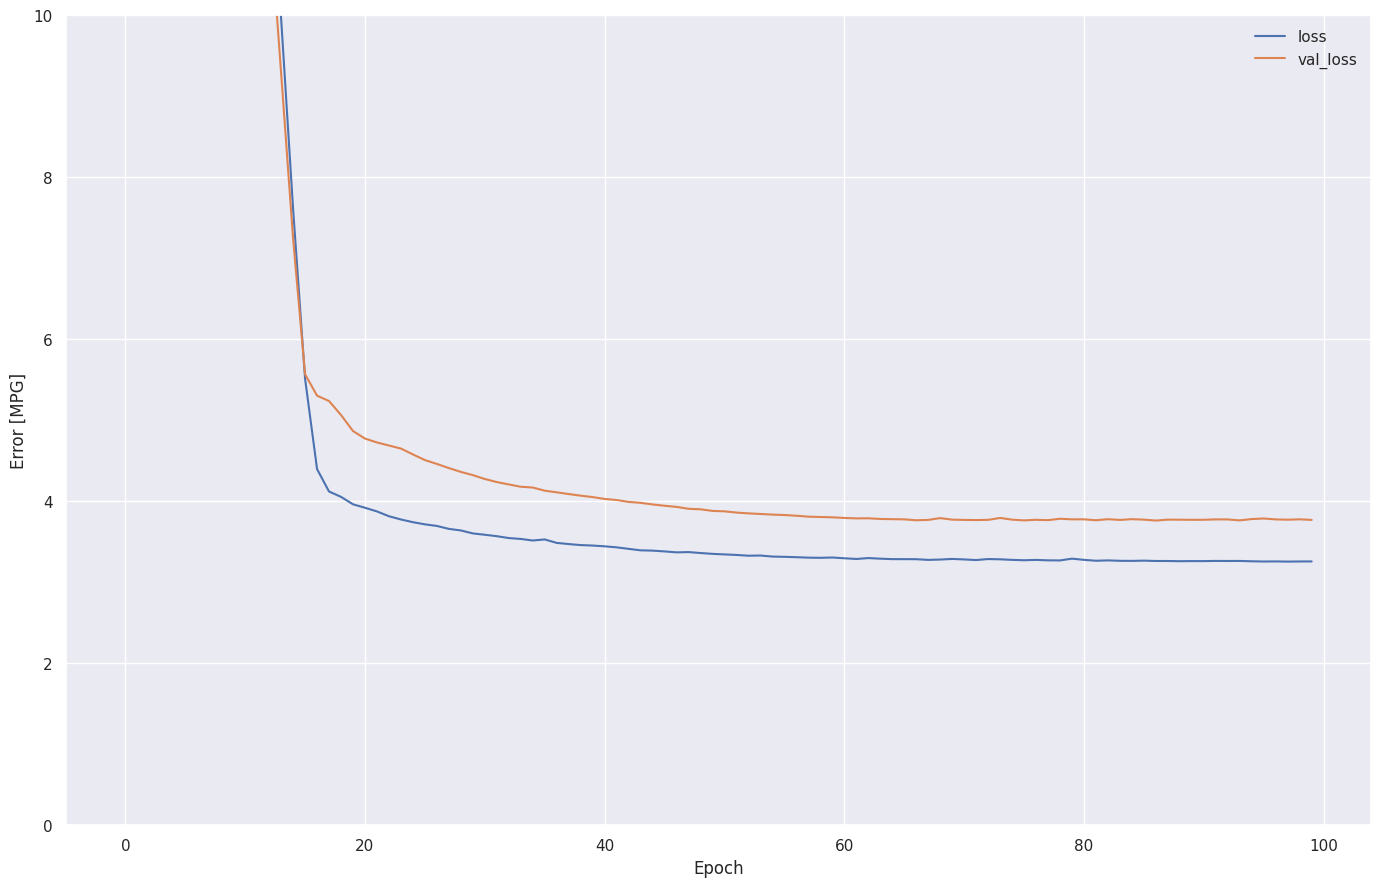

In [ ]:
plot_loss(history)

If you plot the predictions as a function of `Horsepower`, you'll see how this model takes advantage of the nonlinearity provided by the hidden layers:

In [ ]:
x = tf.linspace(0.0, 250, 251)
y = dnn_horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


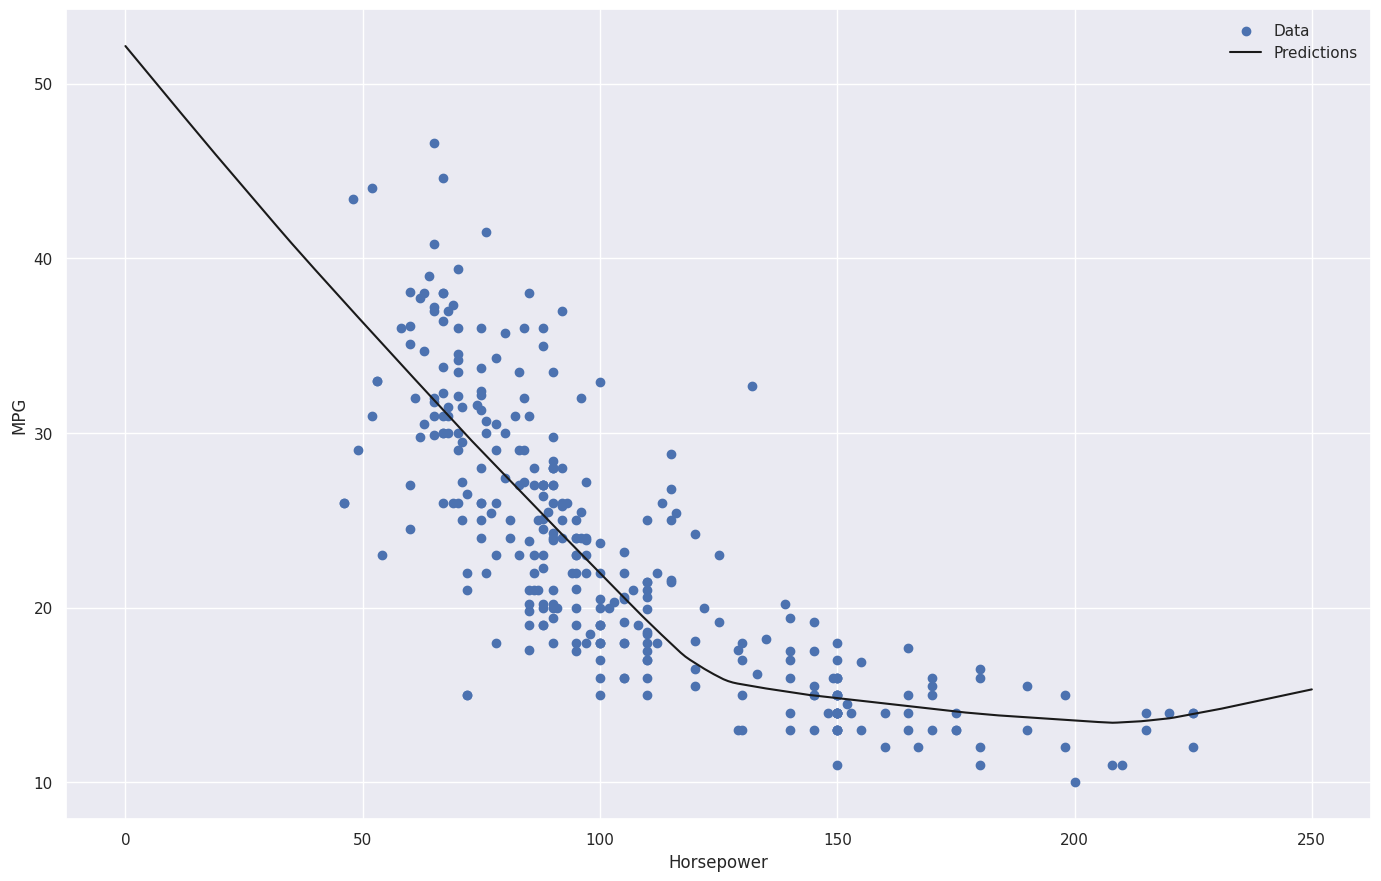

In [ ]:
plot_horsepower(x, y)

Collect the results on the test set, for later:

In [ ]:
test_results['dnn_horsepower_model'] = dnn_horsepower_model.evaluate(
    test_features['Horsepower'], test_labels,
    verbose=0)

### Full model

If you repeat this process using all the inputs it slightly improves the performance on the validation dataset.

In [ ]:
dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (10, 9)                │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [ ]:
%%time
history = dnn_model.fit(
    train_features, train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 10.7 s, sys: 2.23 s, total: 12.9 s
Wall time: 13.6 s


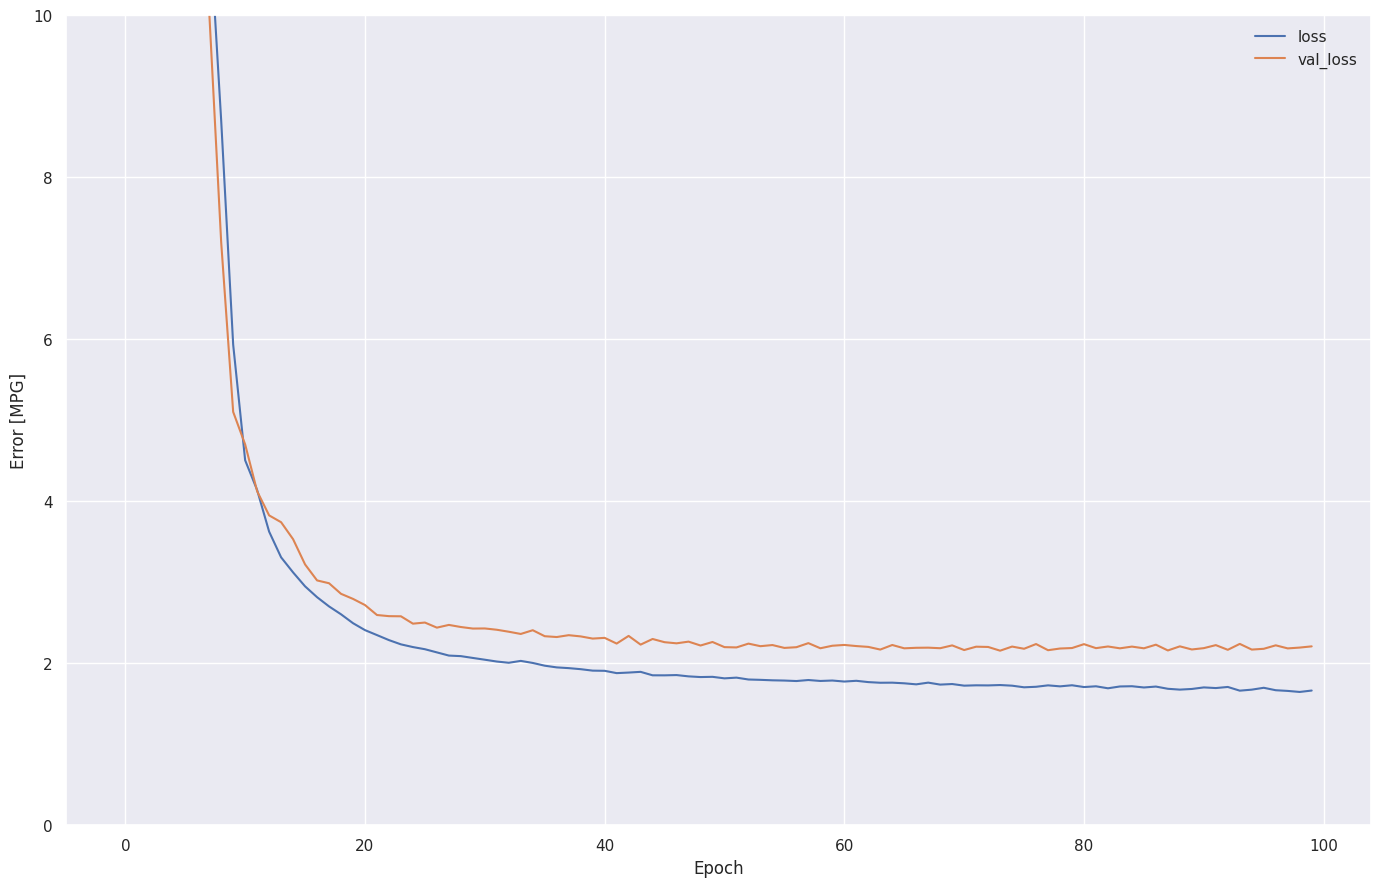

In [ ]:
plot_loss(history)

Collect the results on the test set:

In [ ]:
test_results['dnn_model'] = dnn_model.evaluate(test_features, test_labels, verbose=0)

Explore normalization

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 50.6979 - val_loss: 10.1632
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.3535 - val_loss: 17.3894
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.5363 - val_loss: 9.1353
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 10.8909 - val_loss: 15.7653
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.4248 - val_loss: 8.5106
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.4078 - val_loss: 6.6839
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.1242 - val_loss: 6.7049
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.7748 - val_loss: 8.1631
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.3887 - val_loss: 6.4292
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.8152 - val_loss: 6.8782
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.0032 - val_loss: 6.2183
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.6214

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_92 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,597 (57.02 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,732 (38.02 KB)

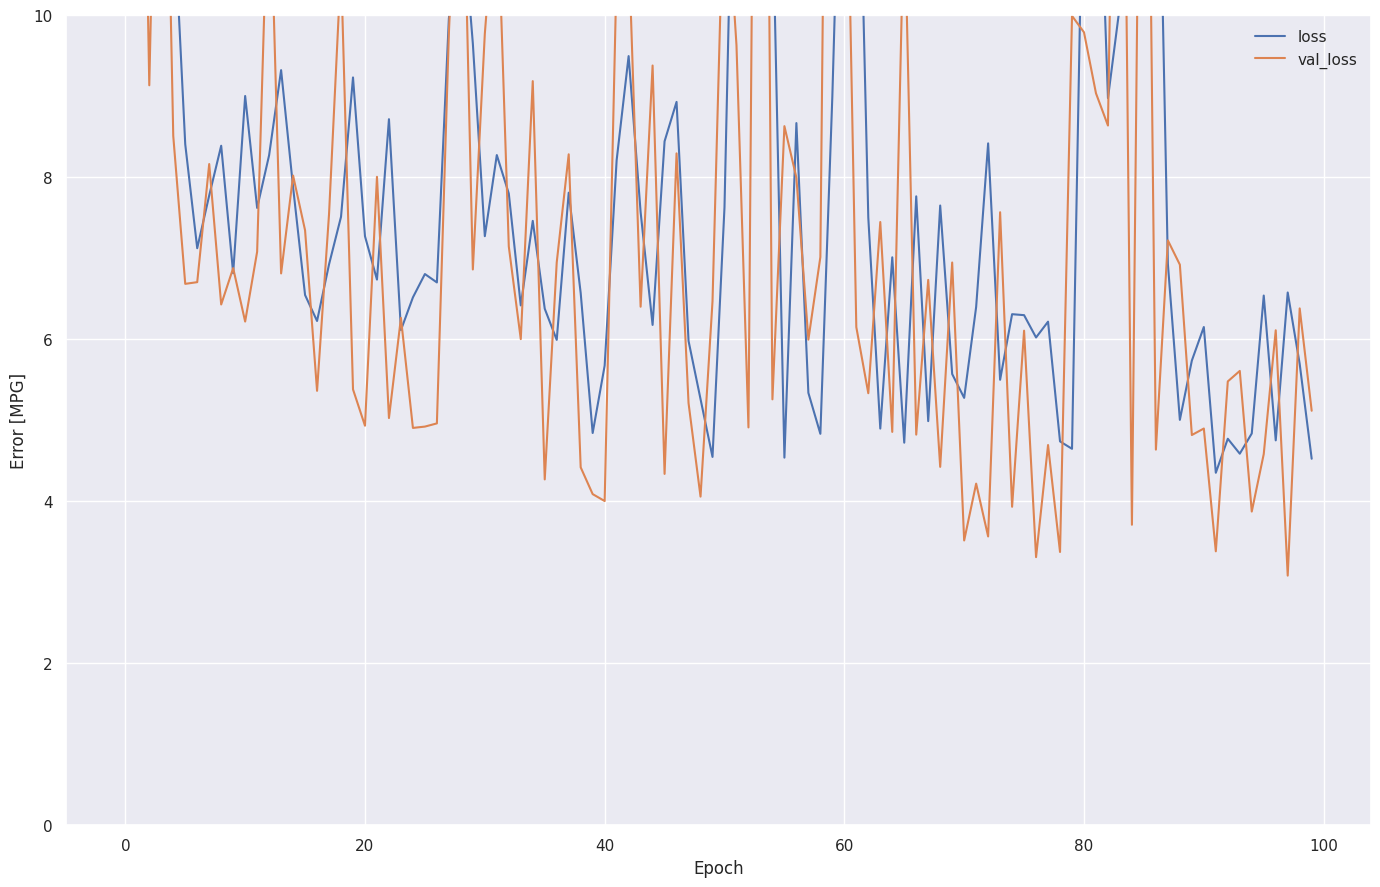

In [ ]:
# X_labels_9var

model_noNorm = keras.Sequential([
      layers.Dense(64, activation='relu'),   # <--- removed norm
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
])

model_noNorm.compile(loss='mean_absolute_error',
  optimizer=tf.keras.optimizers.Adam(0.001))


history = model_noNorm.fit(
  train_features, train_labels,
  validation_split=0.2,
  verbose=1, epochs=100)

plot_loss(history)

model_noNorm.summary()


## Performance

Now that all the models are trained check the test-set performance and see how they did:

In [ ]:
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T

,Mean absolute error [MPG]
horsepower_model,3.937088
linear_model,2.500136
dnn_horsepower_model,2.911190
dnn_model,1.699492


These results match the validation error seen during training.

### Make predictions

Finally, predict have a look at the errors made by the model when making predictions on the test set:

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


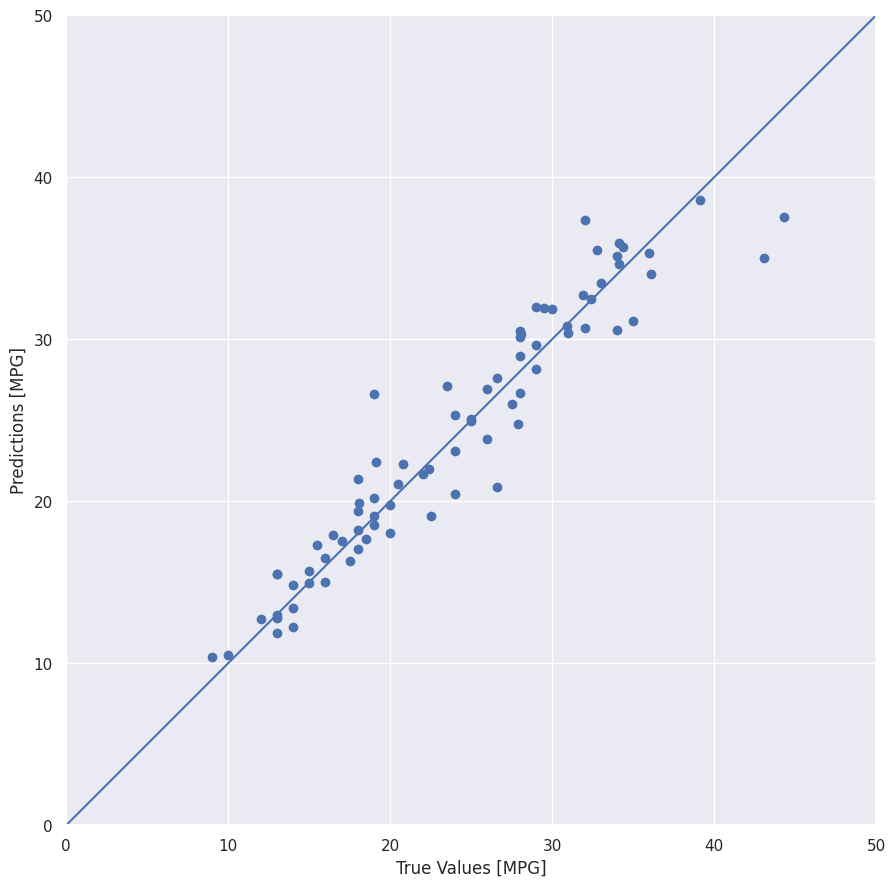

In [ ]:
test_predictions = dnn_model.predict(test_features).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)


It looks like the model predicts reasonably well.

Now take a look at the error distribution:

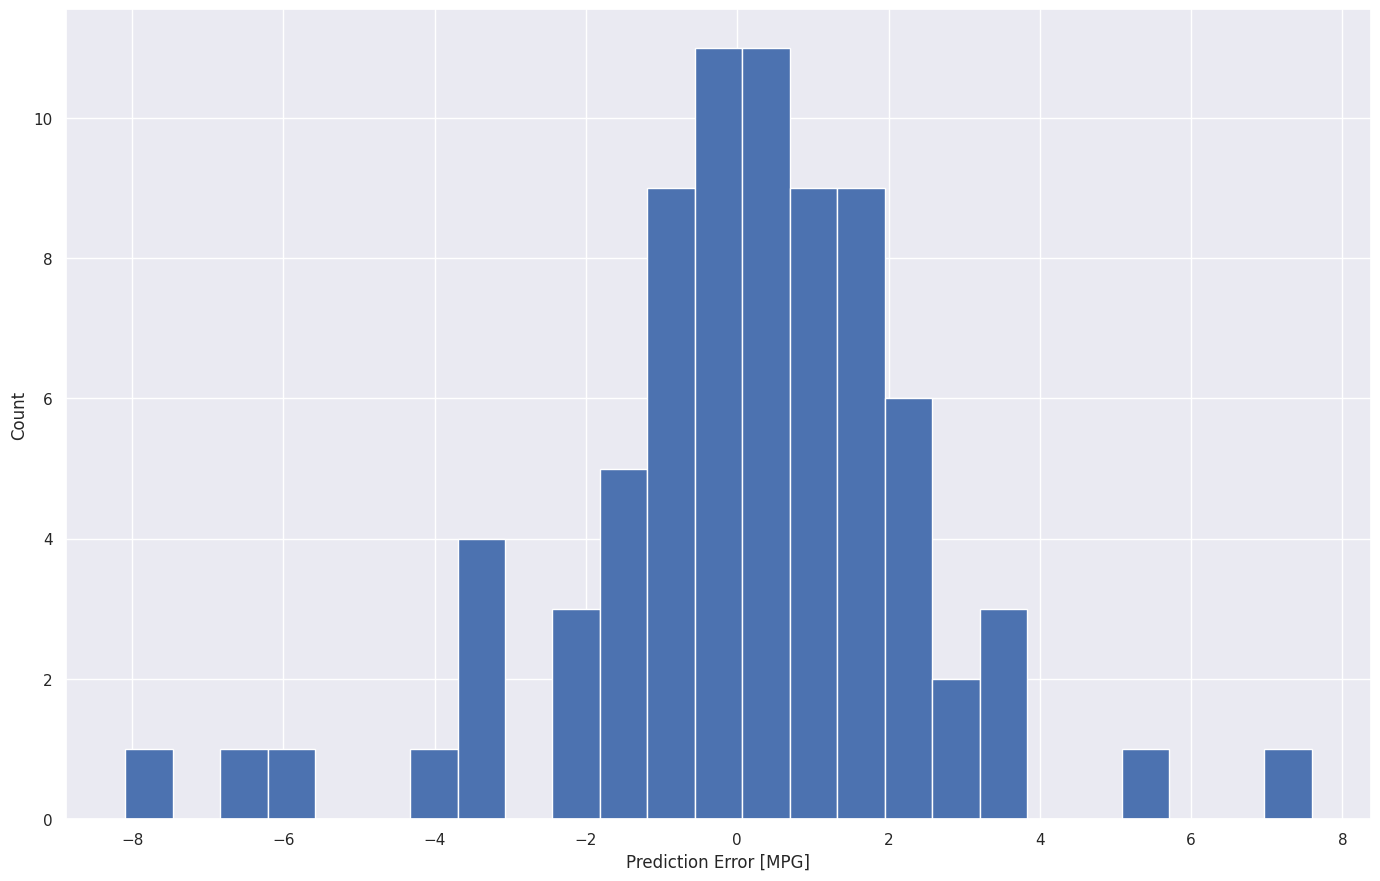

In [ ]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [MPG]')
_ = plt.ylabel('Count')

If you're happy with the model save it for later use:

In [ ]:
dnn_model.save('dnn_model.keras')

If you reload the model, it gives identical output:

In [ ]:
reloaded = tf.keras.models.load_model("https://raw.githubusercontent.com/DataAnalytics808/DASC-522-demo-repository/main/data/dnn_model.keras")

test_results['reloaded'] = reloaded.evaluate(
    test_features, test_labels, verbose=0)

In [ ]:
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T

,Mean absolute error [MPG]
horsepower_model,3.937088
linear_model,2.500136
dnn_horsepower_model,2.911190
dnn_model,1.699492
reloaded,1.699492


## Conclusion

This notebook introduced a few techniques to handle a regression problem. Here are a few more tips that may help:

* [Mean Squared Error (MSE)](https://www.tensorflow.org/api_docs/python/tf/losses/MeanSquaredError) and [Mean Absolute Error (MAE)](https://www.tensorflow.org/api_docs/python/tf/losses/MeanAbsoluteError) are common loss functions used for regression problems. Mean Absolute Error is less sensitive to outliers. Different loss functions are used for classification problems.
* Similarly, evaluation metrics used for regression differ from classification.
* When numeric input data features have values with different ranges, each feature should be scaled independently to the same range.
* Overfitting is a common problem for DNN models, it wasn't a problem for this tutorial. See the [overfit and underfit](overfit_and_underfit.ipynb) tutorial for more help with this.
